# FlashFash shopping behavior

## 1. Check the Data

Before doing any analysis, I'll load the CSV and verify column names, dtypes, and missing values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/shopping.csv')

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


So, there are 3,900 rows and 15 columns. One row per transaction. A few columns have missing values: `Age` and `Location`, `Frequency of Purchases`, and `Review Rating` is missing in some values. `Purchase Amount (USD)` and `Review Rating` are numeric; the rest are mostly categorical strings.

## Question 1: What are the most popular colors by season?

Group the data by `Season` and `Color`, count the orders, and pull the top color in each season.

In [2]:
color_by_season = df.groupby(['Season', 'Color']).size().reset_index(name='orders')

top_color_per_season = (
    color_by_season.sort_values(['Season', 'orders'], ascending=[True, False])
    .groupby('Season')
    .head(1)
    .reset_index(drop=True)
)

print('Top color in each season:')
print(top_color_per_season.to_string(index=False))

Top color in each season:
Season     Color  orders
  Fall     Brown     117
Spring Baby blue      83
Summer  Lavender     120
Winter     Black     155


Each season has its own bestselling color, and the winners aren't the same across the year. That tells me that inventory and merchandising could rotate the featured palette by quarter instead of pushing one hero color.

## Question 2: What is the most popular clothing item by season?

Build a `pivot_table` of item counts by season, then read off the modal item per season and chart the overall top sellers.

Top item per season:
Season
Fall              Socks
Spring    Running Shoes
Summer           Shorts
Winter         Leggings
dtype: str


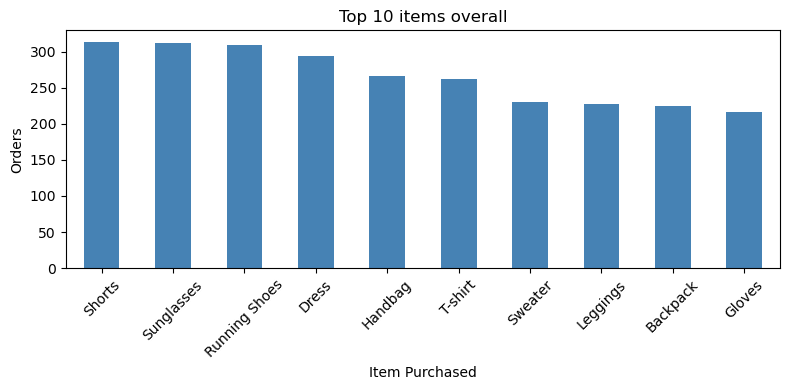

In [3]:
item_pivot = df.pivot_table(
    index='Item Purchased',
    columns='Season',
    aggfunc='size',
    fill_value=0,
)

print('Top item per season:')
print(item_pivot.idxmax())

top_items = df['Item Purchased'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 4))
top_items.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 items overall')
ax.set_ylabel('Orders')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Takeaway.** A handful of items dominate the catalog. Also, the season-by-season winners give a quick stocking signal for each quarter. If FlashFash wants seasonal merchandising wins, the modal item per season is the right place to start.

## Q3: Does using a promo code change the average purchase amount?

Compare the mean `Purchase Amount (USD)` between orders with and without a promo code using `groupby`.

                 count   mean
Promo Code Used              
No                2223  30.17
Yes               1677  50.02


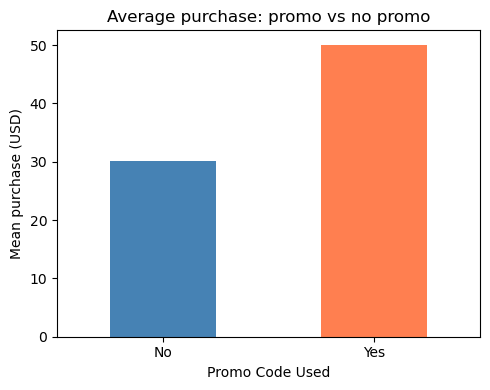

In [4]:
promo_summary = (
    df.groupby('Promo Code Used')['Purchase Amount (USD)']
    .agg(['count', 'mean'])
    .round(2)
)
print(promo_summary)

fig, ax = plt.subplots(figsize=(5, 4))
promo_summary['mean'].plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Average purchase: promo vs no promo')
ax.set_ylabel('Mean purchase (USD)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Promo users actually spend noticeably more on average than non-promo shoppers — about $50 vs $30 per order in this sample. That's a real gap, though it doesn't prove the promo *caused* the bigger basket, bigger-basket shoppers may just be the ones who bother applying codes. Either way, it's a signal worth digging into before trimming the discount program.

## Question 4: When do users leave a review?

Use boolean filtering on `Review Rating` to split orders into reviewed vs not reviewed, then compare how those groups break down by season.

In [5]:
has_review = df['Review Rating'].notna()
print(f'Orders with a review:    {has_review.sum()}')
print(f'Orders without a review: {(~has_review).sum()}')

season_compare = pd.crosstab(df['Season'], has_review, normalize='columns').round(3)
season_compare.columns = ['no_review', 'with_review']
print('\nShare of orders by season (within each group):')
print(season_compare)

Orders with a review:    1431
Orders without a review: 2469

Share of orders by season (within each group):
        no_review  with_review
Season                        
Fall        0.271        0.270
Spring      0.152        0.143
Summer      0.244        0.238
Winter      0.333        0.349


Roughly the same share of orders carry a review across all four seasons, so timing of purchase isn't a strong predictor of who leaves feedback. The missing ratings probably reflect collection gaps in the data rather than seasonal sentiment, which is worth noting before reading too much into review patterns because if there is less data on review, there isn't much to analyse